In [ ]:
# clean single cell data in preparation for metacell
import anndata as ad             # For reading/writing AnnData files
import matplotlib.pyplot as plt  # For plotting
import metacells as mc           # The Metacells package
import numpy as np               # For array/matrix operations
import pandas as pd              # For data frames
import os                        # For filesystem operations
import seaborn as sb             # For plotting
import scipy.sparse as sp        # For sparse matrices
import shutil                    # for filesystem operations
from math import hypot           # For plotting
from typing import *
import scanpy as sc

/mnt/scratch1/miniconda3/envs/metacell_MA/lib/python3.14/site-packages/google_crc32c/__init__.py:29: RuntimeWarning: As the c extension couldn't be imported, `google-crc32c` is using a pure python implementation that is significantly slower. If possible, please configure a c build environment and compile the extension
  warnings.warn(_SLOW_CRC32C_WARNING, RuntimeWarning)


In [2]:
# constants
dataset_name = 'retina'
OUTPUT_DIR = 'metacell_clean/'
dataset_dir = 'cellxgene/'


# genes to explicitly exclude
EXCLUDED_GENE_NAMES = ['XIST', 'MALAT1']  # Sex-specific genes.
EXCLUDED_GENE_PATTERNS = ['MT-.*']        # Mitochondrial.

In [3]:
%%time
full = ad.read_h5ad(dataset_dir + dataset_name + '.h5ad')
full

CPU times: user 2.43 s, sys: 3min 14s, total: 3min 16s
Wall time: 4min 14s


AnnData object with n_obs × n_vars = 244474 × 30172
    obs: 'author_cell_type', 'cell_type'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'default_embedding', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'LVG_embedding', 'X_umap', 'cluster_memberships', 'embedding', 'precluster_denoised', 'precluster_embedding'

In [40]:
# make sure data is float32 (metacell requires this)
full.X = full.X.astype(np.float32)

In [ ]:
# check disease names
full.obs['disease']

In [ ]:
# if filtering for disease
disease = 'myeloid leukemia'
full = full[full.obs['disease'] == disease]
dataset_name = 'aml' # if it needs to be different from original dataset name (e.g. bone marrow -> aml)

In [ ]:
# if filtering for normal
full = full[full.obs['disease'] == 'normal']

In [ ]:
# remove unknown cell types
full = full[full.obs['cell_type'].notna()]
full = full[full.obs['cell_type'] != 'unknown'] 

In [ ]:
# initialize metacell object
mc.ut.top_level(full)
mc.ut.set_name(full, dataset_name + '.full')
full.var_names = full.var.feature_name.tolist()

print(f'full: {full.n_obs} cells, {full.n_vars} genes')

/mnt/scratch1/miniconda3/envs/metacell_MA/lib/python3.14/site-packages/metacells/utilities/annotation.py:980: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["__name__"] = name


full: 77782 cells, 26936 genes


In [30]:
# sum duplicates
mc.ut.sum_duplicates(full.X)

Will exclude 0 (0.00%%) cells with less than 500 UMIs
Will exclude 0 (0.00%%) cells with more than 20000 UMIs


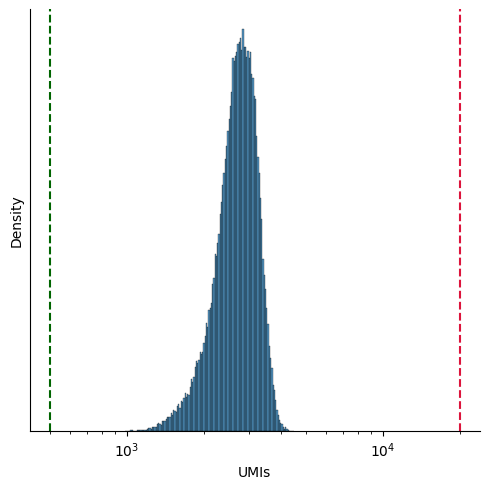

In [ ]:
# excluding low and high umi cells

# just using these as default since most datasets already went through qc
# change as needed based on umi distribution
PROPERLY_SAMPLED_MIN_CELL_TOTAL = 500
PROPERLY_SAMPLED_MAX_CELL_TOTAL = 20000

total_umis_per_cell = mc.ut.get_o_numpy(full, '__x__', sum=True)
plot = sb.displot(total_umis_per_cell, log_scale=(10, None))
plot.set(xlabel='UMIs', ylabel='Density', yticks=[])

plot.refline(x=PROPERLY_SAMPLED_MIN_CELL_TOTAL, color='darkgreen')
plot.refline(x=PROPERLY_SAMPLED_MAX_CELL_TOTAL, color='crimson')

plt.savefig(OUTPUT_DIR + 'figures/' + dataset_name + '_cell_total_umis.svg')

too_small_cells_count = np.sum(total_umis_per_cell < PROPERLY_SAMPLED_MIN_CELL_TOTAL)
too_large_cells_count = np.sum(total_umis_per_cell > PROPERLY_SAMPLED_MAX_CELL_TOTAL)

total_umis_per_cell = mc.ut.get_o_numpy(full, name='__x__', sum=True)
too_small_cells_percent = 100.0 * too_small_cells_count / full.n_obs
too_large_cells_percent = 100.0 * too_large_cells_count / full.n_obs

print(
    f'Will exclude {too_small_cells_count} ({too_small_cells_percent:.2f}%%) cells'
    f' with less than {PROPERLY_SAMPLED_MIN_CELL_TOTAL} UMIs'
)
print(
    f'Will exclude {too_large_cells_count} ({too_large_cells_percent:.2f}%%) cells'
    f' with more than {PROPERLY_SAMPLED_MAX_CELL_TOTAL} UMIs'
)

In [32]:
# excluding genes by name/pattern
mc.pl.exclude_genes(
    full,
    excluded_gene_names=EXCLUDED_GENE_NAMES, 
    excluded_gene_patterns=EXCLUDED_GENE_PATTERNS,
    random_seed=123456,
) 

/mnt/scratch1/miniconda3/envs/metacell_MA/lib/python3.14/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/mnt/scratch1/miniconda3/envs/metacell_MA/lib/python3.14/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
set diabetes2.full.var[bursty_lonely_gene]: 0 true (0%) out of 26936 bools
set diabetes2.full.var[properly_sampled_gene]: 25659 true (95.26%) out of 26936 bools
set diabetes2.full.var[excluded_gene]: 1292 true (4.797%) out of 26936 bools


set diabetes2.full.obs[excluded_umis]: 77782 float32s


Will exclude 0 (0.00%) cells with more than 10.00% excluded gene UMIs


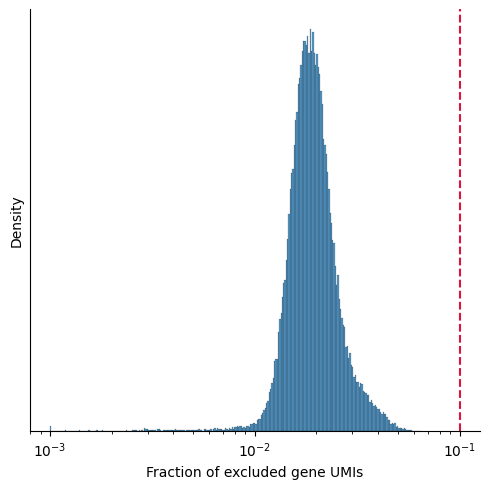

In [33]:
# exclude cells with too high umi for excluded genes (metacell set this at 25%, i'm using 10%)
PROPERLY_SAMPLED_MAX_EXCLUDED_GENES_FRACTION = 0.1

mc.tl.compute_excluded_gene_umis(full)

excluded_umis_fraction_regularization = 1e-3  # Avoid 0 values in log scale plot.
excluded_umis_per_cell = mc.ut.get_o_numpy(full, 'excluded_umis')
excluded_umis_fraction_per_cell = excluded_umis_per_cell / total_umis_per_cell

excluded_umis_fraction_per_cell += excluded_umis_fraction_regularization
plot = sb.displot(excluded_umis_fraction_per_cell, log_scale=(10, None))
excluded_umis_fraction_per_cell -= excluded_umis_fraction_regularization

plot.set(xlabel='Fraction of excluded gene UMIs', ylabel='Density', yticks=[])
plot.refline(x=PROPERLY_SAMPLED_MAX_EXCLUDED_GENES_FRACTION, color='crimson')

plt.savefig(OUTPUT_DIR + 'figures/' + dataset_name + '_cell_excluded_umis_fraction.svg')

too_excluded_cells_count = np.sum(
    excluded_umis_fraction_per_cell > PROPERLY_SAMPLED_MAX_EXCLUDED_GENES_FRACTION
)
too_excluded_cells_fraction = too_excluded_cells_count / len(total_umis_per_cell)

print(
    f'Will exclude {too_excluded_cells_count} ({100 * too_excluded_cells_fraction:.2f}%) cells'
    f' with more than {100 * PROPERLY_SAMPLED_MAX_EXCLUDED_GENES_FRACTION:.2f}% excluded gene UMIs'
)

In [34]:
# exclude cells with high umis of excluded genes
# exclude doublet cells if you know them, there's tools for this if it becomes an issue
if full.obs.columns.str.contains('doublet').any():
    doublet_cells_mask = full.obs.filter(regex='doublet')
    doublet_cells_mask = mc.ut.to_numpy_vector(doublet_cells_mask)
    mc.ut.set_o_data(full, 'doublet_cell', doublet_cells_mask)

    mc.pl.exclude_cells(
    full,
    properly_sampled_min_cell_total=PROPERLY_SAMPLED_MIN_CELL_TOTAL,
    properly_sampled_max_cell_total=PROPERLY_SAMPLED_MAX_CELL_TOTAL,
    properly_sampled_max_excluded_genes_fraction=PROPERLY_SAMPLED_MAX_EXCLUDED_GENES_FRACTION,
    additional_cells_masks=['|doublet_cell']
    )
else:
    mc.pl.exclude_cells(
        full,
        properly_sampled_min_cell_total=PROPERLY_SAMPLED_MIN_CELL_TOTAL,
        properly_sampled_max_cell_total=PROPERLY_SAMPLED_MAX_CELL_TOTAL,
        properly_sampled_max_excluded_genes_fraction=PROPERLY_SAMPLED_MAX_EXCLUDED_GENES_FRACTION
    )

set diabetes2.full.obs[properly_sampled_cell]: 77782 true (100%) out of 77782 bools
set diabetes2.full.obs[excluded_cell]: 0 true (0%) out of 77782 bools


In [35]:
# extract clean data
clean = mc.pl.extract_clean_data(full, name=dataset_name + '.clean')
mc.ut.top_level(clean)
print(f'Clean: {clean.n_obs} cells, {clean.n_vars} genes')

/mnt/scratch1/miniconda3/envs/metacell_MA/lib/python3.14/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
set diabetes2.clean.obs[full_cell_index]: 77782 int32s
set diabetes2.clean.var[full_gene_index]: 25644 int32s


Clean: 77782 cells, 25644 genes


In [ ]:
# filter to necessary obs columns to save space
clean.obs = clean.obs[['cell_type']]
clean

AnnData object with n_obs × n_vars = 77782 × 25644
    obs: 'cell_type'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'bursty_lonely_gene', 'properly_sampled_gene', 'excluded_gene', 'full_gene_index'
    uns: 'batch_condition', 'cell_type_ontology_term_id_colors', 'citation', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title', '__name__'
    obsm: 'X_umap'

In [37]:
# write clean data to output
clean.write_h5ad(OUTPUT_DIR + dataset_name + '.clean.h5ad')